# Case study: Slide-seq mouse colon sp-SVC

## Notebook Guide

Download the five authenticated SCP2038 files, prepare the normal puck
`2020-09-14_Puck_200701_21`, run the formal REVISE sp-SVC route, and inspect
independent UMAPs.  Raw-ST colors come from formal `svc.obs["Level1"]`
labels aligned by observation ID.  The PNG is a historical snapshot and was
not re-run here; missing portal authentication fails naturally in preparation.
Set `REVISE_TACCO_DATA_ROOT` before running.
Phase 1 snapshot: this streamlined code has not been rerun.

**Question.** What does the authenticated normal puck produce under sp-SVC?
**Method.** Prepare the exact portal files and run the configured route.
**Direct observation.** The retained image is the historical UMAP snapshot.
**Interpretation boundary.** Missing authentication stops preparation; no
substitute data are inferred.


In [ ]:
import os
from pathlib import Path
import subprocess
import sys

for key in (
    "OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMBA_NUM_THREADS",
):
    os.environ[key] = "1"
os.environ["PYTHONHASHSEED"] = "42"
os.environ["MPLBACKEND"] = "Agg"
SEED = 42

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(SEED)

REPO_ROOT = Path.cwd().resolve()
TACCO_CASE_DIR = REPO_ROOT / "reproduce/case/tacco"

DATA_ROOT = Path(os.environ["REVISE_TACCO_DATA_ROOT"]).expanduser().resolve()
os.environ["REVISE_TACCO_DATA_ROOT"] = str(DATA_ROOT)
PREPARE_SCRIPT = TACCO_CASE_DIR / "prepare_cases.py"
RUN_ENV = os.environ.copy()
RUN_ENV["REVISE_TACCO_DATA_ROOT"] = str(DATA_ROOT)
RUN_ENV["PYTHONPATH"] = str(REPO_ROOT)
RUN_ENV["MPLBACKEND"] = "Agg"


## 1. Prepare the authenticated SCP2038 source

The preparation command requires the exact authenticated Single Cell Portal
artifacts; no substitute data are accepted.


In [ ]:
subprocess.run(
    [sys.executable, str(PREPARE_SCRIPT), "colon"],
    cwd=REPO_ROOT,
    env=RUN_ENV,
    check=True,
)


In [ ]:
CASE_ROOT = DATA_ROOT / "prepared/slideseq_mouse_colon"
ST_PATH = CASE_ROOT / "normal_Puck_200701_21.h5ad"
REFERENCE_PATH = CASE_ROOT / "normal_scRNAseq.h5ad"
raw_st = ad.read_h5ad(ST_PATH)
reference = ad.read_h5ad(REFERENCE_PATH)


## 2. Run the formal TACCO-backed REVISE sp-SVC route


In [ ]:
CONFIG_PATH = TACCO_CASE_DIR / "configs/SlideSeq_mouse_colon_sp_SVC.yaml"
command = [
    sys.executable,
    str(REPO_ROOT / "reconstruct.py"),
    "--config",
    str(CONFIG_PATH),
]
subprocess.run(command, cwd=DATA_ROOT, env=RUN_ENV, check=True)


In [ ]:
SVC_PATH = DATA_ROOT / (
    "results/slideseq_mouse_colon/SlideSeq_mouse_colon_sp_SVC.h5ad"
)
svc = ad.read_h5ad(SVC_PATH)


## 3. Independent expression-space UMAPs

Each source is fitted independently with direct Scanpy preprocessing and
UMAP.  The raw-ST panel uses the formal
SVC `Level1` labels, with index alignment, and does not repeat complete GA.
The selected configuration uses `strength = 0.0` and joint-graph `alpha = 0.8`.


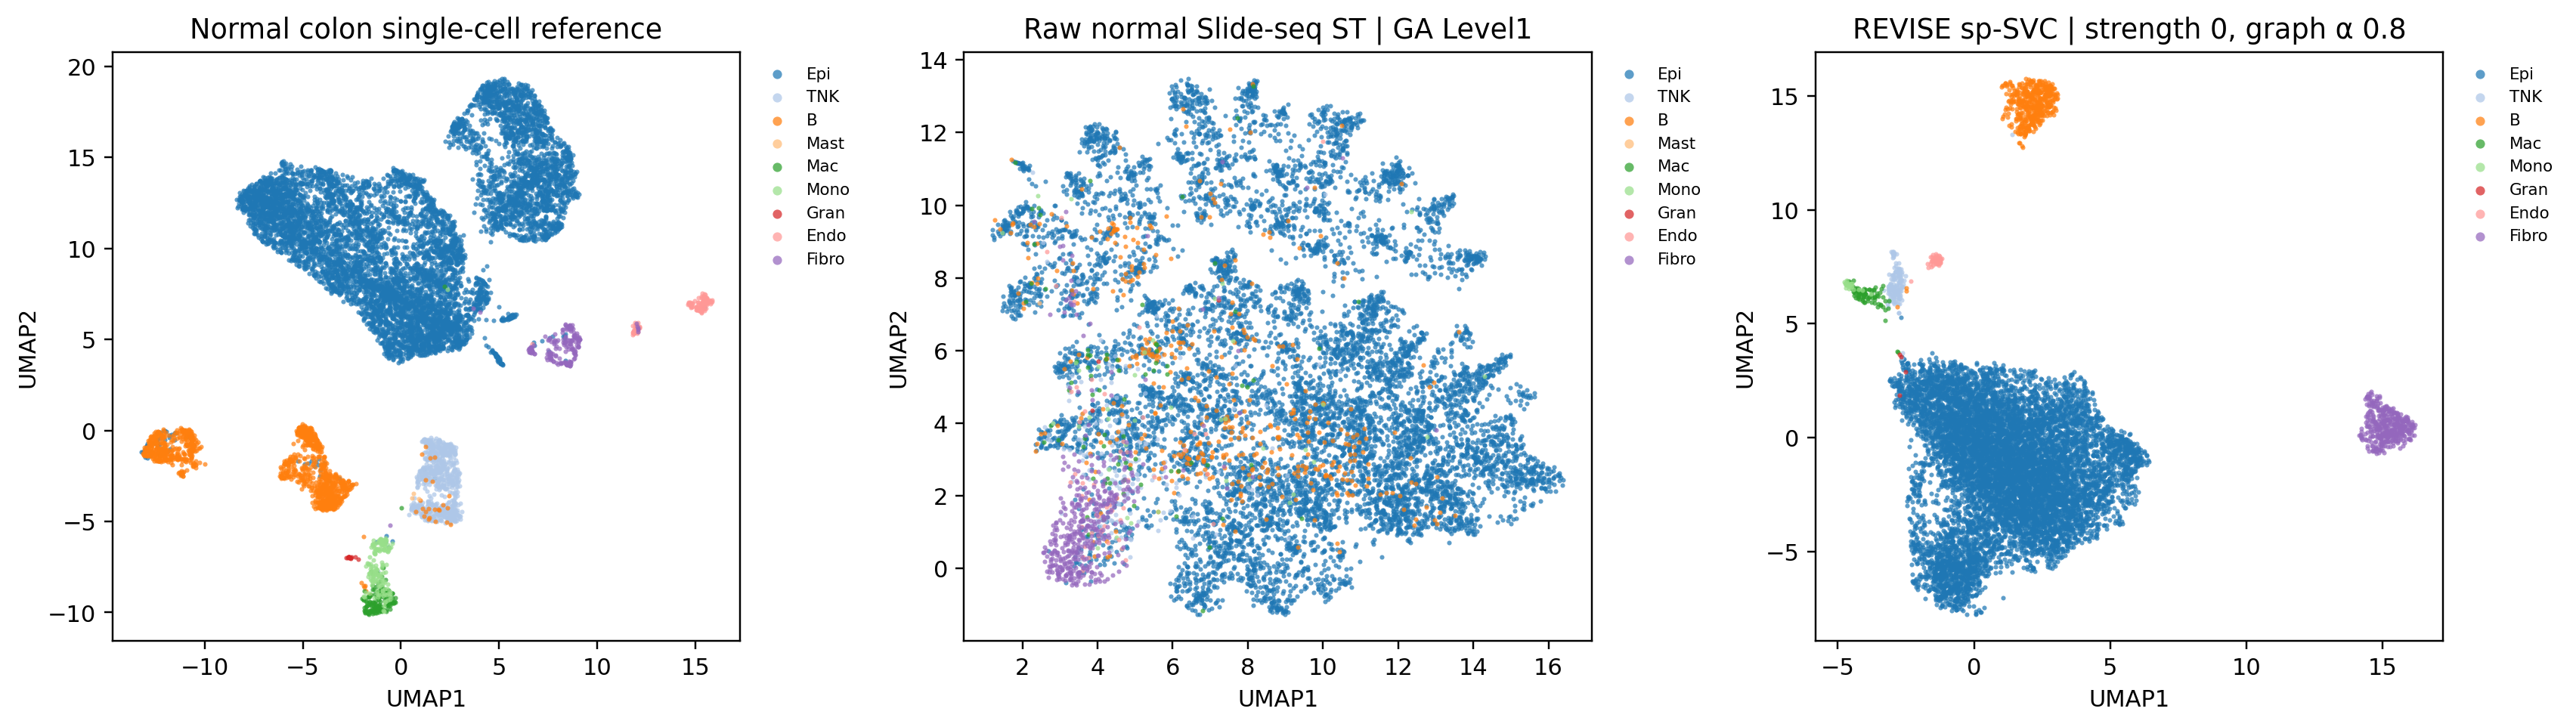

In [ ]:
import scanpy as sc

raw_for_umap = raw_st[
    np.asarray(raw_st.X.sum(axis=1)).ravel() >= 50
].copy()
umap_objects = {
    "reference": reference.copy(),
    "raw_st": raw_for_umap.copy(),
    "svc": svc.copy(),
}
svc_level1 = svc.obs["Level1"].astype(str)
umap_objects["raw_st"].obs["Level1"] = (
    svc_level1.loc[raw_for_umap.obs_names].to_numpy()
)
for adata in umap_objects.values():
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.pca(adata, n_comps=30, random_state=SEED)
    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, random_state=SEED)
    sc.tl.umap(adata, random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), squeeze=False)
for ax, (name, title) in zip(
    axes.ravel(),
    (
        ("reference", "Normal colon single-cell reference"),
        ("raw_st", "Raw normal Slide-seq ST | formal SVC Level1"),
        ("svc", "REVISE sp-SVC | strength 0, graph alpha 0.8"),
    ),
):
    sc.pl.umap(
        umap_objects[name],
        color="Level1",
        title=title,
        size=4,
        frameon=False,
        legend_loc="none",
        ax=ax,
        show=False,
    )
plt.tight_layout()
plt.show()


## Interpretation boundary

UMAP orientation, scale, and distance are source-local.  This gallery snapshot
records a formal reconstruction workflow; it is not an independent biological
validation of the SCP2038 case.
